# Automated Healthcare Insight Generation

## Assignment 4 analysis notebook

This notebook complements the Streamlit application by explaining and reproducing the complete analytics pipeline on the supplied district-level healthcare dataset. It reuses the project's production functions instead of creating a second analytics implementation.

**Objectives:** validate the data, detect trends and statistical outliers, calculate Pearson correlations, generate structured rule-based insights, visualize findings, and export reproducible CSV outputs.

**Stack:** Python, Pandas, Matplotlib, and the reusable service modules in `src/`. No LLM, prediction model, or separate API is used.

## End-to-end workflow

The notebook follows the same data flow as `app.py`: raw CSV -> validation -> safe cleaned copy -> filtered analysis -> trends, outliers, correlations -> structured insights -> charts and CSV exports.

```mermaid
flowchart LR
    A[Healthcare CSV] --> B[Load and validate]
    B --> C[Clean analysis copy]
    C --> D[Trend detection]
    C --> E[IQR or Z-score outliers]
    C --> F[Pearson correlations]
    D --> G[Insight generation]
    E --> G
    F --> G
    G --> H[Charts and CSV exports]
```

## Imports and configuration

The path logic supports both execution from the project root and execution from the `notebooks/` directory. Thresholds match the assignment and Streamlit defaults: 10% trend change, 0.70 absolute correlation, IQR multiplier 1.5, and Z-score threshold 3.

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Find the repository whether this notebook is opened from the root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.correlation_analysis import correlation_matrix, flagged_correlations
from src.data_loader import (
    REQUIRED_COLUMNS,
    clean_data,
    numeric_summary,
    prepare_analysis_data,
    validate_dataset,
)
from src.insight_generator import INSIGHT_COLUMNS, add_threshold_breaches, generate_insights
from src.outlier_detection import detect_outliers
from src.trend_detection import detect_trends
from src.visualizations import correlation_heatmap, district_line_chart, severity_bar_chart

DATA_PATH = PROJECT_ROOT / 'data' / 'healthcare_performance.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
TREND_THRESHOLD = 10.0
CORRELATION_THRESHOLD = 0.70
IQR_MULTIPLIER = 1.5
ZSCORE_THRESHOLD = 3.0
print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset: {DATA_PATH}')

Project root: c:\Users\Asus Vivobook\Auto-Analytics-Engine
Dataset: c:\Users\Asus Vivobook\Auto-Analytics-Engine\data\healthcare_performance.csv


## Load the dataset

The assignment dataset has one row per district and month. The percentage indicators represent coverage or delivery performance; `high_risk_cases` is a raw count.

In [3]:
data = pd.read_csv(DATA_PATH)
print('First five rows:')
display(data.head())
print('Shape:', data.shape)
print('Columns:', data.columns.tolist())
print('Data types:')
display(data.dtypes.rename('dtype').to_frame())
print('Missing values per column:')
display(data.isna().sum().rename('missing').to_frame())

First five rows:


,month,district,anc_coverage,institutional_delivery,immunization,high_risk_cases
0,2026-07,Ahmedabad,85,91,93,10
1,2026-08,Ahmedabad,69,90,92,13
2,2026-07,Surat,81,87,91,13
3,2026-08,Surat,83,89,92,12
4,2026-07,Vadodara,90,93,96,7


Shape: (12, 6)
Columns: ['month', 'district', 'anc_coverage', 'institutional_delivery', 'immunization', 'high_risk_cases']
Data types:


,dtype
month,object
district,object
anc_coverage,int64
institutional_delivery,int64
immunization,int64
high_risk_cases,int64


Missing values per column:


,missing
month,0
district,0
anc_coverage,0
institutional_delivery,0
immunization,0
high_risk_cases,0


| Indicator | Meaning |
| --- | --- |
| `anc_coverage` | Antenatal care coverage percentage |
| `institutional_delivery` | Institutional delivery percentage |
| `immunization` | Immunization coverage percentage |
| `high_risk_cases` | Count of high-risk cases |

## Data validation and preparation

Validation checks the required schema, `YYYY-MM` month values, numeric indicator types, duplicate district/month keys, missing values, and suspicious numeric ranges. Range findings are warnings rather than invented hard constraints. Cleaning creates a deep copy, fills missing values, and removes exact duplicate rows; the source DataFrame remains unchanged.

In [4]:
validation = validate_dataset(data)
print('Required columns:', REQUIRED_COLUMNS)
print('Validation valid:', validation['valid'])
print('Errors:', validation['errors'])
print('Warnings:', validation.get('warnings', []))
print('Duplicate district/month records:', validation['duplicate_key_count'])

cleaned, cleaning_report = clean_data(data)
analysis_data = prepare_analysis_data(cleaned)
print('Cleaning report:', cleaning_report)
print('Prepared analysis rows:', len(analysis_data))
display(analysis_data.head())

Required columns: ['month', 'district', 'anc_coverage', 'institutional_delivery', 'immunization', 'high_risk_cases']
Validation valid: True
Errors: []
Warnings: []
Duplicate district/month records: 0
Cleaning report: {'missing_filled': 0, 'duplicates_removed': 0}
Prepared analysis rows: 12


,month,district,anc_coverage,institutional_delivery,immunization,high_risk_cases,_month_date
0,2026-07,Ahmedabad,85,91,93,10,2026-07-01
1,2026-08,Ahmedabad,69,90,92,13,2026-08-01
2,2026-07,Surat,81,87,91,13,2026-07-01
3,2026-08,Surat,83,89,92,12,2026-08-01
4,2026-07,Vadodara,90,93,96,7,2026-07-01


## Exploratory data analysis

The summary statistics describe the numeric indicators. The distribution plots show how values vary across the six districts and two months, while the grouped comparison highlights the average performance by district.

,count,mean,median,min,max
anc_coverage,12.0,78.33,80.5,42.0,91.0
institutional_delivery,12.0,88.17,88.5,82.0,94.0
immunization,12.0,91.58,91.5,87.0,97.0
high_risk_cases,12.0,13.42,13.0,6.0,28.0


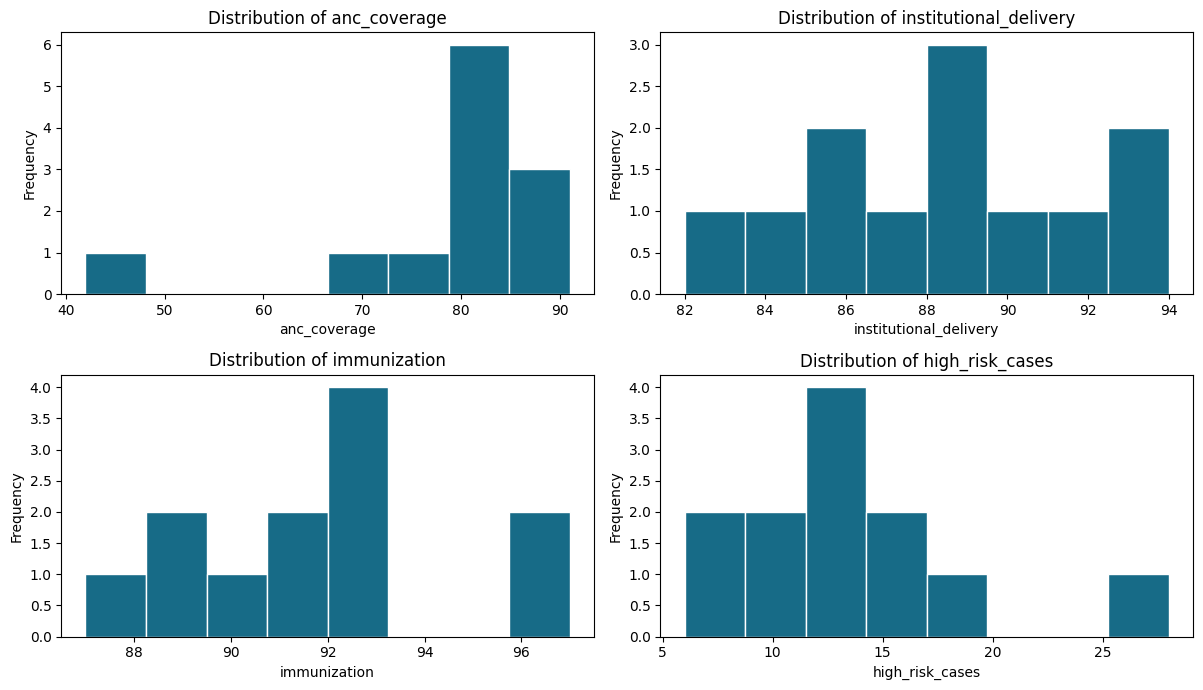

,anc_coverage,institutional_delivery,immunization,high_risk_cases
district,,,,
Ahmedabad,77.0,90.5,92.5,11.5
Bhavnagar,78.0,83.0,88.0,16.0
Mehsana,63.0,88.5,91.5,19.5
Rajkot,79.5,85.5,89.5,14.5
Surat,82.0,88.0,91.5,12.5
Vadodara,90.5,93.5,96.5,6.5


In [5]:
indicators = [column for column in REQUIRED_COLUMNS if column not in {'month', 'district'}]
display(numeric_summary(analysis_data))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for axis, indicator in zip(axes.flat, indicators):
    analysis_data[indicator].plot(kind='hist', bins=8, ax=axis, color='#176b87', edgecolor='white')
    axis.set_title(f'Distribution of {indicator}')
    axis.set_xlabel(indicator)
    axis.set_ylabel('Frequency')
fig.tight_layout()
plt.show()

district_means = analysis_data.groupby('district')[indicators].mean().round(2)
display(district_means)

## Trend detection

For each district and indicator, the existing service sorts valid months and compares each observation with the immediately preceding available observation:

`change_pct = ((current_value - previous_value) / previous_value) * 100`

A trend is significant when `abs(change_pct) >= 10%`. If the previous value is zero, the service emits no percentage and does not flag a misleading infinite change.

In [6]:
trends = detect_trends(analysis_data, TREND_THRESHOLD, indicators)
display(trends)

ahmedabad_anc = trends[(trends['district'] == 'Ahmedabad') & (trends['indicator'] == 'anc_coverage')].iloc[0]
print(f"Ahmedabad ANC: {ahmedabad_anc['previous_value']} -> {ahmedabad_anc['current_value']} = {ahmedabad_anc['change_pct']:.2f}%")
assert round(ahmedabad_anc['change_pct'], 2) == -18.82
assert bool(ahmedabad_anc['is_significant'])
print('Verification passed: the Ahmedabad ANC change is significant at the default threshold.')

,district,indicator,previous_month,month,previous_value,current_value,change_pct,threshold,direction,is_significant
0,Ahmedabad,anc_coverage,2026-07,2026-08,85.0,69,-18.823529,10.0,Decrease,True
1,Ahmedabad,high_risk_cases,2026-07,2026-08,10.0,13,30.000000,10.0,Increase,True
2,Ahmedabad,immunization,2026-07,2026-08,93.0,92,-1.075269,10.0,Decrease,False
3,Ahmedabad,institutional_delivery,2026-07,2026-08,91.0,90,-1.098901,10.0,Decrease,False
4,Bhavnagar,anc_coverage,2026-07,2026-08,77.0,79,2.597403,10.0,Increase,False
5,Bhavnagar,high_risk_cases,2026-07,2026-08,17.0,15,-11.764706,10.0,Decrease,True
6,Bhavnagar,immunization,2026-07,2026-08,87.0,89,2.298851,10.0,Increase,False
7,Bhavnagar,institutional_delivery,2026-07,2026-08,82.0,84,2.439024,10.0,Increase,False
8,Mehsana,anc_coverage,2026-07,2026-08,84.0,42,-50.000000,10.0,Decrease,True
9,Mehsana,high_risk_cases,2026-07,2026-08,11.0,28,154.545455,10.0,Increase,True


Ahmedabad ANC: 85.0 -> 69 = -18.82%
Verification passed: the Ahmedabad ANC change is significant at the default threshold.


With only two months per district, each district has at most one comparable change. Missing months are not fabricated: the immediately preceding available valid month is used, and districts with fewer than two usable observations produce no trend row.

## Outlier detection

The default IQR rule is applied per indicator across the prepared dataset:

- `IQR = Q3 - Q1`
- `lower_bound = Q1 - 1.5 * IQR`
- `upper_bound = Q3 + 1.5 * IQR`

The same service also supports Z-score detection with a configurable threshold of 3. Constant and undersized series are skipped. The district and value below are selected from computed results only; no district is hardcoded into the detection algorithm.

In [7]:
outliers_iqr = detect_outliers(analysis_data, 'IQR', IQR_MULTIPLIER, ZSCORE_THRESHOLD, indicators)
display(outliers_iqr)

mehsana_anc = outliers_iqr[(outliers_iqr['district'] == 'Mehsana') & (outliers_iqr['indicator'] == 'anc_coverage') & (outliers_iqr['value'] == 42)]
print('Mehsana ANC value 42 detected:', not mehsana_anc.empty)
assert not mehsana_anc.empty

outliers_zscore = detect_outliers(analysis_data, 'Z-score', IQR_MULTIPLIER, ZSCORE_THRESHOLD, indicators)
print('Z-score result rows:', len(outliers_zscore))

,district,indicator,month,value,method,lower_bound,upper_bound,threshold
0,Ahmedabad,anc_coverage,2026-08,69,IQR,69.875,92.875,1.5
1,Mehsana,anc_coverage,2026-08,42,IQR,69.875,92.875,1.5
2,Vadodara,immunization,2026-08,97,IQR,86.000,96.000,1.5
3,Mehsana,high_risk_cases,2026-08,28,IQR,4.375,21.375,1.5


Mehsana ANC value 42 detected: True
Z-score result rows: 0


## Correlation analysis

Pearson correlation ranges from -1 to +1. Values near +1 indicate a positive linear relationship; values near -1 indicate a negative linear relationship. The service flags unique indicator pairs when `abs(r) >= 0.70`, excludes self-pairs, and skips insufficient or constant pairs.

The sample has only 12 rows and two months per district. Correlations are therefore fragile exploratory signals and do not establish causation.

In [8]:
corr_matrix = correlation_matrix(analysis_data, indicators)
display(corr_matrix.round(3))

flagged_pairs = flagged_correlations(analysis_data, CORRELATION_THRESHOLD, indicators)
display(flagged_pairs)
assert not any(row.indicator_a == row.indicator_b for row in flagged_pairs.itertuples())
assert len({tuple(sorted(pair)) for pair in zip(flagged_pairs.indicator_a, flagged_pairs.indicator_b)}) == len(flagged_pairs)

,anc_coverage,institutional_delivery,immunization,high_risk_cases
anc_coverage,1.000,0.283,0.373,-0.933
institutional_delivery,0.283,1.000,0.979,-0.563
immunization,0.373,0.979,1.000,-0.620
high_risk_cases,-0.933,-0.563,-0.620,1.000


,indicator_a,indicator_b,correlation,correlation_coefficient,observations,threshold,interpretation
0,anc_coverage,high_risk_cases,-0.933495,-0.933495,12,0.7,negative relationship
1,institutional_delivery,immunization,0.978608,0.978608,12,0.7,positive relationship


## Automated insight generation

The centralized generator combines trend, outlier, and correlation results. Each record uses the required stable schema. Trend severity is Medium at the configured threshold and High at twice the threshold; outlier severity is based on distance beyond the calculated bounds; correlation severity is Low, Medium, or High by coefficient strength. These are rule-based analytics, not machine-learning predictions.

In [9]:
insights = generate_insights(trends, outliers_iqr, flagged_pairs, TREND_THRESHOLD)
insights = add_threshold_breaches(insights, analysis_data, 'anc_coverage', 70.0)
print('Insight types:', sorted(insights['type'].unique()))
assert list(insights.columns) == INSIGHT_COLUMNS
assert insights['insight_id'].is_unique
assert set(insights['severity']).issubset({'Low', 'Medium', 'High'})
display(insights)

Insight types: ['correlation', 'outlier', 'threshold_breach', 'trend']


,insight_id,type,indicator,entity,period,value,prev_value,change_pct,severity,explanation
0,INS-0001,trend,anc_coverage,Ahmedabad,2026-08,69.000000,85.0,-18.823529,Medium,anc_coverage in Ahmedabad decreased from 85.00...
1,INS-0002,trend,high_risk_cases,Ahmedabad,2026-08,13.000000,10.0,30.000000,High,high_risk_cases in Ahmedabad increased from 10...
2,INS-0003,trend,high_risk_cases,Bhavnagar,2026-08,15.000000,17.0,-11.764706,Medium,high_risk_cases in Bhavnagar decreased from 17...
3,INS-0004,trend,anc_coverage,Mehsana,2026-08,42.000000,84.0,-50.000000,High,anc_coverage in Mehsana decreased from 84.00 t...
4,INS-0005,trend,high_risk_cases,Mehsana,2026-08,28.000000,11.0,154.545455,High,high_risk_cases in Mehsana increased from 11.0...
5,INS-0006,trend,high_risk_cases,Vadodara,2026-08,6.000000,7.0,-14.285714,Medium,high_risk_cases in Vadodara decreased from 7.0...
6,INS-0007,outlier,anc_coverage,Ahmedabad,2026-08,69.000000,NaN,NaN,Medium,anc_coverage for Ahmedabad was 69.00 in 2026-0...
7,INS-0008,outlier,anc_coverage,Mehsana,2026-08,42.000000,NaN,NaN,High,"anc_coverage for Mehsana was 42.00 in 2026-08,..."
8,INS-0009,outlier,immunization,Vadodara,2026-08,97.000000,NaN,NaN,Medium,immunization for Vadodara was 97.00 in 2026-08...
9,INS-0010,outlier,high_risk_cases,Mehsana,2026-08,28.000000,NaN,NaN,Medium,high_risk_cases for Mehsana was 28.00 in 2026-...


## Visualization

These plots reuse the project's visualization functions. The severity chart summarizes generated findings, the heatmap shows the complete Pearson matrix, and the district line chart shows the selected indicator over chronological months.

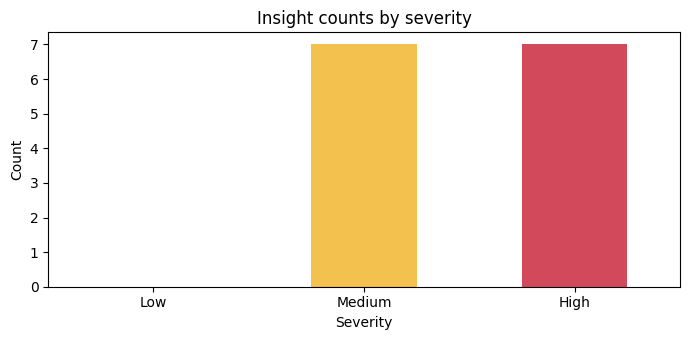

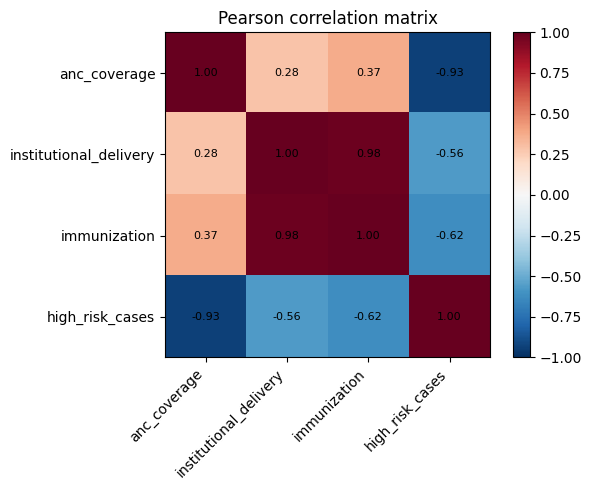

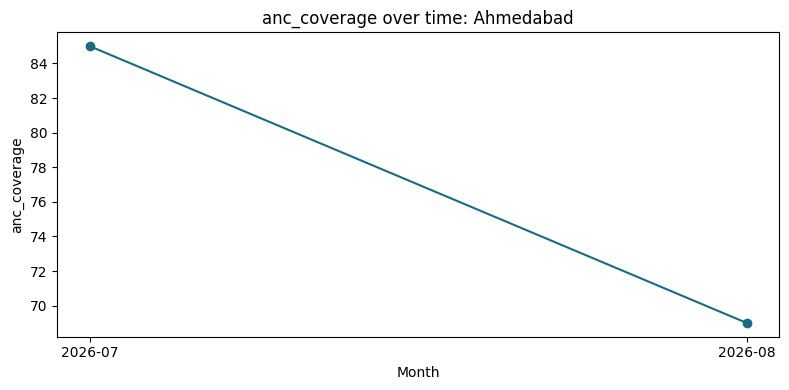

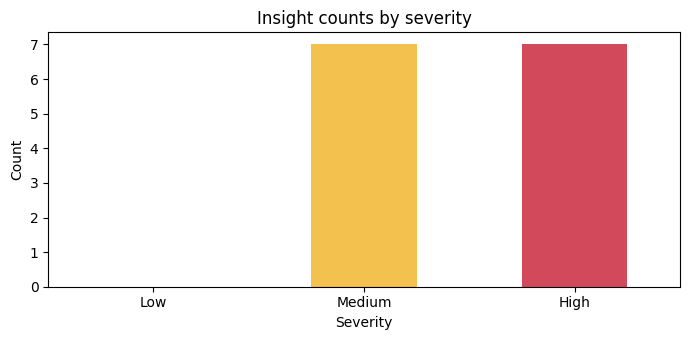

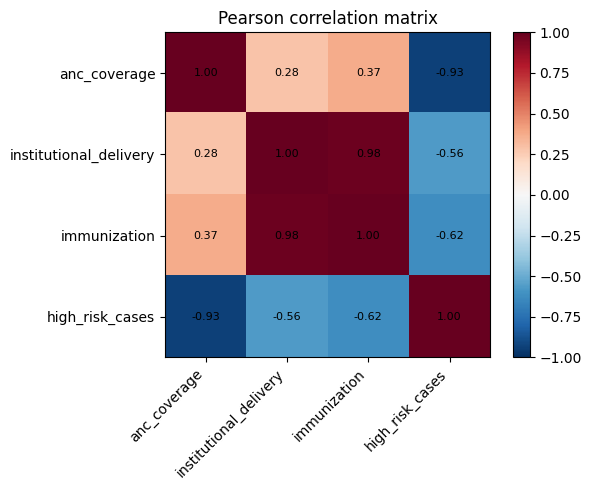

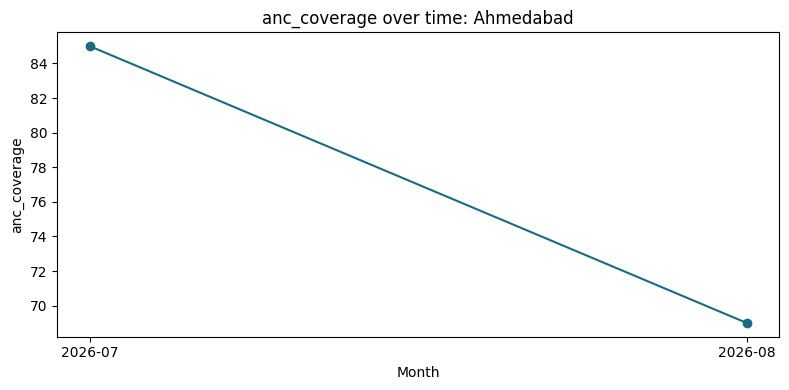

In [10]:
display(severity_bar_chart(insights))
display(correlation_heatmap(corr_matrix))
display(district_line_chart(analysis_data, 'Ahmedabad', 'anc_coverage'))

## Export results

The exports below use the same complete, unfiltered sample analysis as the application output. They do not overwrite the source dataset. The insights CSV has the required field order; the correlation CSV preserves indicator labels as its index.

In [11]:
OUTPUT_DIR.mkdir(exist_ok=True)
insights_path = OUTPUT_DIR / 'insights.csv'
correlation_path = OUTPUT_DIR / 'correlation_matrix.csv'
insights.to_csv(insights_path, index=False)
corr_matrix.to_csv(correlation_path)

saved_insights = pd.read_csv(insights_path)
saved_correlation = pd.read_csv(correlation_path, index_col=0)
assert saved_insights.columns.tolist() == INSIGHT_COLUMNS
assert saved_correlation.shape == corr_matrix.shape
print('Saved:', insights_path)
print('Saved:', correlation_path)
display(saved_insights.head())
display(saved_correlation.round(3))

Saved: c:\Users\Asus Vivobook\Auto-Analytics-Engine\outputs\insights.csv
Saved: c:\Users\Asus Vivobook\Auto-Analytics-Engine\outputs\correlation_matrix.csv


,insight_id,type,indicator,entity,period,value,prev_value,change_pct,severity,explanation
0,INS-0001,trend,anc_coverage,Ahmedabad,2026-08,69.0,85.0,-18.823529,Medium,anc_coverage in Ahmedabad decreased from 85.00...
1,INS-0002,trend,high_risk_cases,Ahmedabad,2026-08,13.0,10.0,30.000000,High,high_risk_cases in Ahmedabad increased from 10...
2,INS-0003,trend,high_risk_cases,Bhavnagar,2026-08,15.0,17.0,-11.764706,Medium,high_risk_cases in Bhavnagar decreased from 17...
3,INS-0004,trend,anc_coverage,Mehsana,2026-08,42.0,84.0,-50.000000,High,anc_coverage in Mehsana decreased from 84.00 t...
4,INS-0005,trend,high_risk_cases,Mehsana,2026-08,28.0,11.0,154.545455,High,high_risk_cases in Mehsana increased from 11.0...


,anc_coverage,institutional_delivery,immunization,high_risk_cases
anc_coverage,1.000,0.283,0.373,-0.933
institutional_delivery,0.283,1.000,0.979,-0.563
immunization,0.373,0.979,1.000,-0.620
high_risk_cases,-0.933,-0.563,-0.620,1.000


## Final conclusions and limitations

The computed results show several data-driven review signals, including a large Ahmedabad ANC decrease, a Mehsana ANC outlier, a large Mehsana high-risk-case increase, and strong indicator relationships. The exact values and explanations above are generated from the CSV and service outputs.

This is automated descriptive analytics and rule-based insight generation, not model training or forecasting. The dataset has only two observations per district, so trend conclusions are limited and correlations are unstable. Stronger analysis would require more monthly history, a larger district population, documented clinical/business thresholds, and additional contextual variables such as service capacity, population denominators, and reporting quality.